# 03 — Baseline Models for DeepLOB Comparison

This notebook evaluates 3 baseline models against our trained DeepLOB models on the FI-2010 dataset
(Setup 2, DecPre normalization) across all 5 prediction horizons (k=10, 20, 30, 50, 100).

**Baselines** (trained via `scripts/train_baselines.py` and `scripts/retrain_mlp.py`):
1. **Logistic Regression** — sklearn, saga solver, on flattened (N, 4000) input
2. **MLP** — 2-layer NN (128→64) with BatchNorm, StandardScaler, ReduceLROnPlateau
3. **XGBoost** — 100 gradient-boosted trees, max_depth=6, hist method

---

###  Background: Why Baselines Matter

In machine learning research, **baselines** are simpler models that serve as a reference point.
They answer: *"Does the complex model actually learn something the simple ones can't?"*

If DeepLOB can't beat a logistic regression, the deep learning complexity isn't justified.
If it beats everything, we know the CNN+LSTM architecture captures patterns that simpler models miss.

###  The Models at a Glance

| Model | Type | Key Idea | Parameters | Can Learn Non-Linear? | Uses 2D Structure? |
|-------|------|----------|------------|----------------------|-------------------|
| **Logistic Regression** | Linear classifier | Weighted sum of features → softmax | ~12K |  No |  No |
| **MLP** | Neural network | Stacked linear layers + ReLU activations | ~520K |  Yes |  No |
| **XGBoost** | Ensemble of trees | Sequentially fits trees on residual errors | ~100 trees |  Yes (tree splits) |  No |
| **DeepLOB** | CNN + LSTM | Conv2d for spatial, LSTM for temporal patterns | ~144K |  Yes |  Yes |

**Key insight:** All baselines receive a **flattened** (N, 4000) vector. They cannot "see" that the input
is really a (100 timesteps × 40 LOB features) matrix. DeepLOB processes it as a 2D image, preserving
the spatial (across LOB levels) and temporal (across time) structure.

###  Input Representation

```
Original LOB window: (100, 40) — 100 timesteps, 40 features per timestep
                                  (10 price levels × 4 values: ask_price, ask_vol, bid_price, bid_vol)

For baselines:  flatten → (4000,) — one long vector, structure lost
For DeepLOB:    reshape → (1, 100, 40) — single-channel "image", structure preserved
```

###  Key Metrics Explained

- **Accuracy** = (correct predictions) / (total predictions). Simple but misleading with imbalanced classes.
- **Weighted F1** = F1 score weighted by class support (number of samples per class). Better for imbalanced data.
- **Precision** = Of all predictions for class X, how many were actually X? (avoids false positives)
- **Recall** = Of all actual class X samples, how many did we find? (avoids false negatives)
- **F1** = Harmonic mean of precision and recall. Balances both.

### Contents
1. Load saved predictions and DeepLOB results
2. Comparison table: accuracy and weighted F1
3. Accuracy comparison bar chart
4. F1 comparison bar chart
5. DeepLOB advantage heatmap
6. Classification reports per baseline
7. Discussion

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, f1_score

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

HORIZONS = [10, 20, 30, 50, 100]
CLASS_NAMES = ["Down", "Stationary", "Up"]
BASELINES_DIR = PROJECT_ROOT / "experiments" / "baselines"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/tt/Individual Projects/deeplob-project


## 1. Load Saved Results

Baseline predictions from `experiments/baselines/*.pt` (trained via scripts).
DeepLOB results from `experiments/k{horizon}/history.pt`.

 **Study note — Training setup:**
- **LogReg & XGBoost:** Trained on combined train+val data (254,651 samples) since they don't need
  a validation set for early stopping. More training data = better performance.
- **MLP:** Trained on train set only (203,720 samples), using val set (50,931) for early stopping.
  This is the same split DeepLOB uses, so the comparison is fair.
- **Test set:** 139,488 samples, chronologically after training data (no data leakage).

In [2]:
# Load baseline results
baseline_names = ["logistic_regression", "mlp", "xgboost"]
display_names = {"logistic_regression": "LogReg", "mlp": "MLP", "xgboost": "XGBoost"}

baselines = {}
for name in baseline_names:
    baselines[name] = {}
    for h in HORIZONS:
        data = torch.load(BASELINES_DIR / f"{name}_k{h}.pt", weights_only=False)
        baselines[name][h] = data
        print(f"{display_names[name]:>8s} k={h:3d}: acc={data['accuracy']*100:.2f}%, F1={data['f1_weighted']*100:.2f}%, time={data['train_time']:.1f}s")
    print()

  LogReg k= 10: acc=72.20%, F1=62.79%, time=727.5s
  LogReg k= 20: acc=63.67%, F1=54.56%, time=770.3s
  LogReg k= 30: acc=57.90%, F1=53.63%, time=1090.0s
  LogReg k= 50: acc=50.23%, F1=50.40%, time=839.7s
  LogReg k=100: acc=47.62%, F1=40.58%, time=1007.9s

     MLP k= 10: acc=70.73%, F1=58.90%, time=54.9s
     MLP k= 20: acc=62.79%, F1=51.53%, time=39.6s
     MLP k= 30: acc=56.75%, F1=55.11%, time=172.4s
     MLP k= 50: acc=51.16%, F1=51.56%, time=290.1s
     MLP k=100: acc=52.18%, F1=51.01%, time=236.4s

 XGBoost k= 10: acc=80.16%, F1=77.45%, time=250.6s
 XGBoost k= 20: acc=71.99%, F1=68.20%, time=254.6s
 XGBoost k= 30: acc=72.89%, F1=71.12%, time=252.2s
 XGBoost k= 50: acc=71.82%, F1=71.38%, time=251.5s
 XGBoost k=100: acc=66.53%, F1=66.54%, time=255.5s



In [3]:
# Load DeepLOB results
deeplob = {}
for h in HORIZONS:
    history = torch.load(
        PROJECT_ROOT / "experiments" / f"k{h}" / "history.pt",
        map_location="cpu", weights_only=False,
    )
    deeplob[h] = {
        "accuracy": history["test_accuracy"],
        "f1_weighted": history.get("test_f1_weighted", None),
    }
    print(f"DeepLOB k={h:3d}: acc={deeplob[h]['accuracy']*100:.2f}%")

DeepLOB k= 10: acc=81.88%
DeepLOB k= 20: acc=73.77%
DeepLOB k= 30: acc=76.14%
DeepLOB k= 50: acc=77.34%
DeepLOB k=100: acc=78.19%


## 2. Comparison Tables

 **Study note — Reading the comparison table:**
- **"Gap"** = baseline accuracy minus DeepLOB accuracy. Negative means DeepLOB wins.
- The gap tells you how much value DeepLOB's architecture adds over simpler approaches.
- A small gap (e.g., -1.72 for XGBoost at k=10) means the baseline nearly matches DeepLOB.
- A large gap (e.g., -30.57 for LogReg at k=100) means DeepLOB is dramatically better.

 **Study note — Why accuracy can be misleading:**
- At k=10, the "Stationary" class is 70.7% of test data. A model that always predicts "Stationary"
  gets 70.7% accuracy for free! This is called the **majority-class baseline**.
- That's why we also look at **weighted F1**, which penalizes models that ignore minority classes.

In [4]:
# Accuracy comparison table
rows = []
for h in HORIZONS:
    row = {
        "Horizon": f"k={h}",
        "DeepLOB": f"{deeplob[h]['accuracy']*100:.2f}",
    }
    for name in baseline_names:
        acc = baselines[name][h]["accuracy"]
        gap = (acc - deeplob[h]["accuracy"]) * 100
        row[display_names[name]] = f"{acc*100:.2f}"
        row[f"{display_names[name]} Gap"] = f"{gap:+.2f}"
    rows.append(row)

df_acc = pd.DataFrame(rows)
print("Test Accuracy (%) — All Models x All Horizons")
print("=" * 85)
print(df_acc.to_string(index=False))
print("\nGap = baseline - DeepLOB (negative = DeepLOB wins)")

Test Accuracy (%) — All Models x All Horizons
Horizon DeepLOB LogReg LogReg Gap   MLP MLP Gap XGBoost XGBoost Gap
   k=10   81.88  72.20      -9.67 70.73  -11.15   80.16       -1.72
   k=20   73.77  63.67     -10.11 62.79  -10.99   71.99       -1.78
   k=30   76.14  57.90     -18.24 56.75  -19.38   72.89       -3.25
   k=50   77.34  50.23     -27.12 51.16  -26.18   71.82       -5.52
  k=100   78.19  47.62     -30.57 52.18  -26.01   66.53      -11.66

Gap = baseline - DeepLOB (negative = DeepLOB wins)


In [5]:
# Weighted F1 comparison table
f1_rows = []
for h in HORIZONS:
    row = {"Horizon": f"k={h}"}
    dl_f1 = deeplob[h].get("f1_weighted")
    row["DeepLOB"] = f"{dl_f1*100:.2f}" if dl_f1 else "—"
    for name in baseline_names:
        row[display_names[name]] = f"{baselines[name][h]['f1_weighted']*100:.2f}"
    f1_rows.append(row)

df_f1 = pd.DataFrame(f1_rows)
print("\nWeighted F1 (%) — All Models x All Horizons")
print("=" * 65)
print(df_f1.to_string(index=False))


Weighted F1 (%) — All Models x All Horizons
Horizon DeepLOB LogReg   MLP XGBoost
   k=10       —  62.79 58.90   77.45
   k=20       —  54.56 51.53   68.20
   k=30       —  53.63 55.11   71.12
   k=50       —  50.40 51.56   71.38
  k=100       —  40.58 51.01   66.54


## 3. Accuracy Comparison Bar Chart

 **Study note — How to read the bar chart:**
- Each group of 4 bars represents one prediction horizon (k=10 through k=100).
- DeepLOB (blue) should be the tallest bar in every group if it's the best model.
- The gap between DeepLOB and the best baseline grows as the horizon increases — this is a key finding.

 **Study note — What the horizons mean:**
- **k=10**: Predict price direction 10 events (~seconds) ahead. Very short-term, highly imbalanced (70% stationary).
- **k=100**: Predict price direction 100 events (~minutes) ahead. More balanced classes, harder temporal patterns.
- Short horizons favor models that handle class imbalance well.
- Long horizons favor models that capture temporal dependencies.

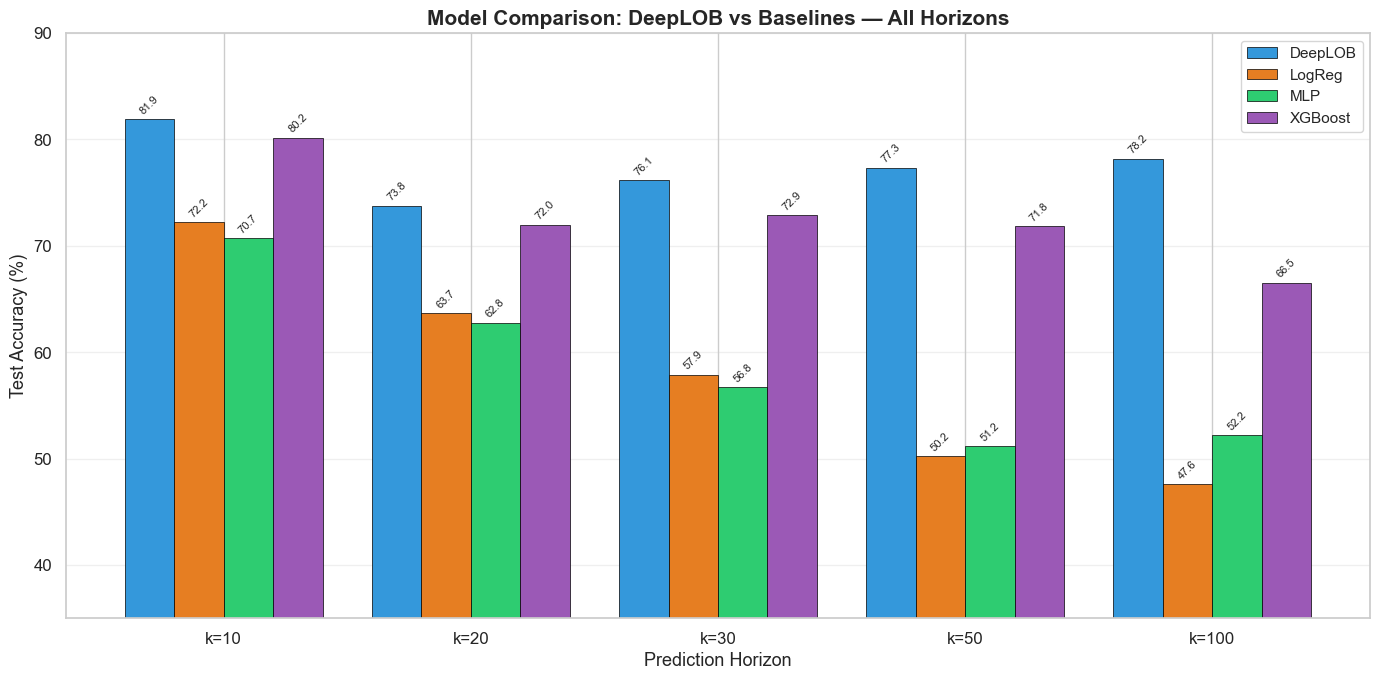

Saved to experiments/baselines/accuracy_comparison_all_models.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

model_labels = ["DeepLOB", "LogReg", "MLP", "XGBoost"]
colors = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6"]
x = np.arange(len(HORIZONS))
width = 0.2

all_accs = {
    "DeepLOB": [deeplob[h]["accuracy"] * 100 for h in HORIZONS],
    "LogReg": [baselines["logistic_regression"][h]["accuracy"] * 100 for h in HORIZONS],
    "MLP": [baselines["mlp"][h]["accuracy"] * 100 for h in HORIZONS],
    "XGBoost": [baselines["xgboost"][h]["accuracy"] * 100 for h in HORIZONS],
}

for i, (name, color) in enumerate(zip(model_labels, colors)):
    bars = ax.bar(
        x + (i - 1.5) * width, all_accs[name], width,
        label=name, color=color, edgecolor="black", linewidth=0.5,
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8, rotation=45,
        )

ax.set_xlabel("Prediction Horizon", fontsize=13)
ax.set_ylabel("Test Accuracy (%)", fontsize=13)
ax.set_title("Model Comparison: DeepLOB vs Baselines — All Horizons", fontsize=15, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"k={h}" for h in HORIZONS])
ax.set_ylim(35, 90)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(BASELINES_DIR / "accuracy_comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/baselines/accuracy_comparison_all_models.png")

## 4. Weighted F1 Comparison Bar Chart

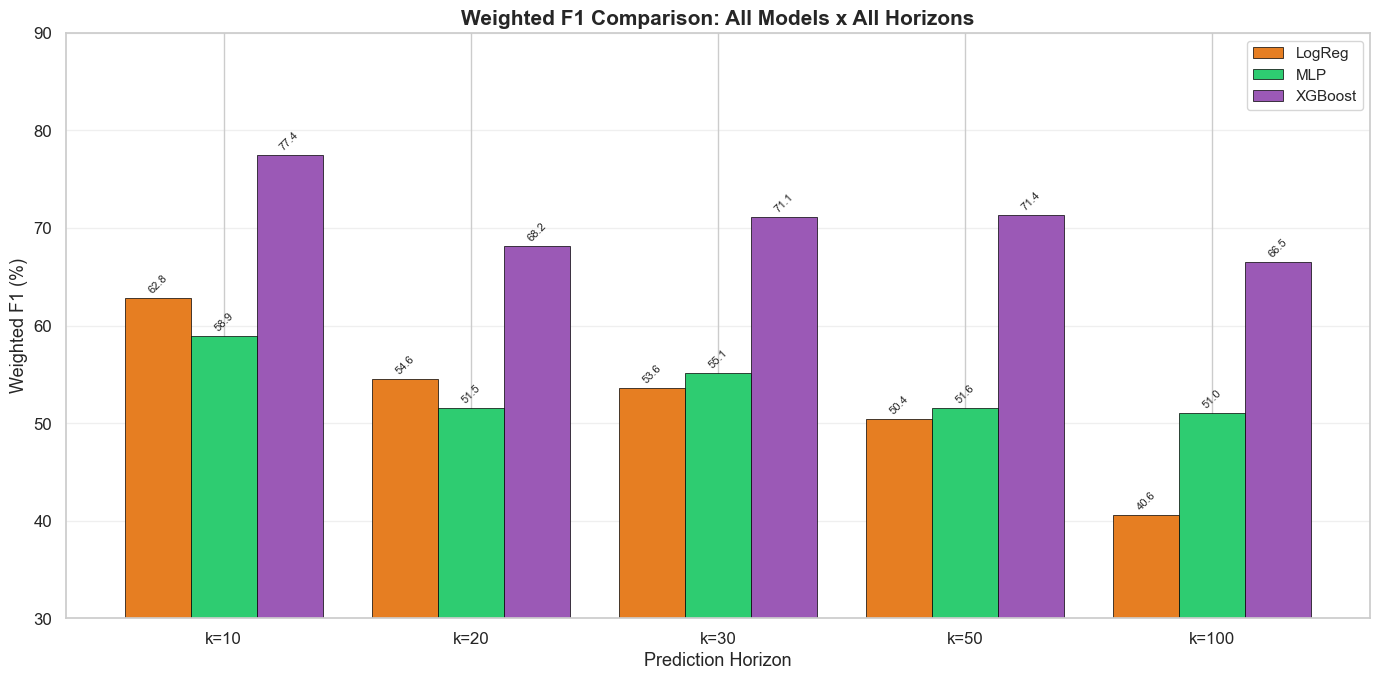

Saved to experiments/baselines/f1_comparison_all_models.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

all_f1s = {
    "LogReg": [baselines["logistic_regression"][h]["f1_weighted"] * 100 for h in HORIZONS],
    "MLP": [baselines["mlp"][h]["f1_weighted"] * 100 for h in HORIZONS],
    "XGBoost": [baselines["xgboost"][h]["f1_weighted"] * 100 for h in HORIZONS],
}

# Add DeepLOB F1 if available
dl_f1_available = all(deeplob[h].get("f1_weighted") is not None for h in HORIZONS)
if dl_f1_available:
    all_f1s = {"DeepLOB": [deeplob[h]["f1_weighted"] * 100 for h in HORIZONS], **all_f1s}
    f1_labels = ["DeepLOB", "LogReg", "MLP", "XGBoost"]
    f1_colors = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6"]
else:
    f1_labels = ["LogReg", "MLP", "XGBoost"]
    f1_colors = ["#e67e22", "#2ecc71", "#9b59b6"]

n_models = len(f1_labels)
width = 0.8 / n_models

for i, (name, color) in enumerate(zip(f1_labels, f1_colors)):
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(
        x + offset, all_f1s[name], width,
        label=name, color=color, edgecolor="black", linewidth=0.5,
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8, rotation=45,
        )

ax.set_xlabel("Prediction Horizon", fontsize=13)
ax.set_ylabel("Weighted F1 (%)", fontsize=13)
ax.set_title("Weighted F1 Comparison: All Models x All Horizons", fontsize=15, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"k={h}" for h in HORIZONS])
ax.set_ylim(30, 90)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(BASELINES_DIR / "f1_comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/baselines/f1_comparison_all_models.png")

## 5. DeepLOB Advantage Heatmap

 **Study note — Reading the heatmap:**
- **Green cells** = DeepLOB has a large advantage (it wins by many percentage points).
- **Yellow/Red cells** = Small advantage or DeepLOB loses.
- The color intensity shows how dominant DeepLOB is over that specific baseline at that horizon.
- Numbers are in **percentage points (pp)**: "+11.7" means DeepLOB is 11.7 percentage points better.

 **Study note — The diagonal pattern:**
- Notice the advantage grows from top-left to bottom-left (short→long horizons).
- This tells us DeepLOB's temporal modeling (LSTM) matters MORE for longer predictions.
- At k=10, XGBoost nearly matches DeepLOB because short-term patterns are simpler.
- At k=100, even XGBoost falls behind by ~12pp because it can't model temporal sequences.

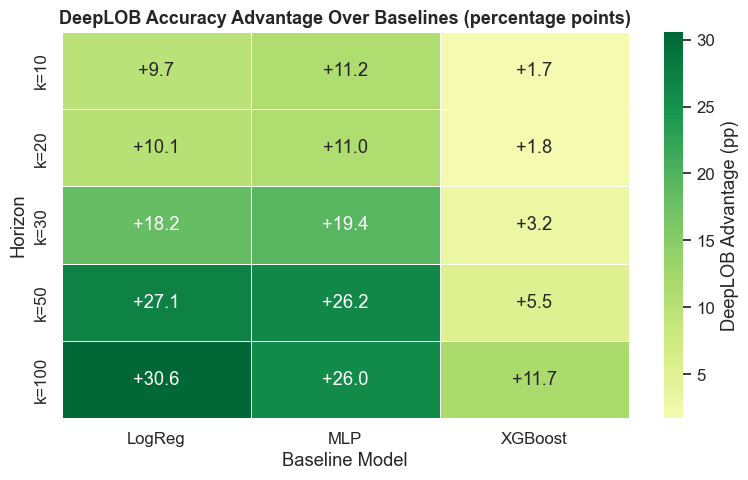

Saved to experiments/baselines/deeplob_advantage_heatmap.png


In [8]:
advantage_data = []
for h in HORIZONS:
    dl_acc = deeplob[h]["accuracy"] * 100
    advantage_data.append({
        "LogReg": dl_acc - baselines["logistic_regression"][h]["accuracy"] * 100,
        "MLP": dl_acc - baselines["mlp"][h]["accuracy"] * 100,
        "XGBoost": dl_acc - baselines["xgboost"][h]["accuracy"] * 100,
    })

df_adv = pd.DataFrame(advantage_data, index=[f"k={h}" for h in HORIZONS])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    df_adv, annot=True, fmt="+.1f", cmap="RdYlGn", center=0,
    ax=ax, linewidths=0.5, cbar_kws={"label": "DeepLOB Advantage (pp)"},
)
ax.set_title("DeepLOB Accuracy Advantage Over Baselines (percentage points)", fontsize=13, fontweight="bold")
ax.set_ylabel("Horizon")
ax.set_xlabel("Baseline Model")

plt.tight_layout()
plt.savefig(BASELINES_DIR / "deeplob_advantage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/baselines/deeplob_advantage_heatmap.png")

## 6. Classification Reports Per Baseline

 **Study note — How to read a classification report:**

```
              precision    recall  f1-score   support
        Down     0.7972    0.3784    0.5132     21127    ← XGBoost k=10 example
  Stationary     0.8040    0.9738    0.8808     98602
          Up     0.7772    0.3946    0.5234     19759
```

- **Precision** for "Down" = 0.80 means: when the model predicts "Down", it's correct 80% of the time.
- **Recall** for "Down" = 0.38 means: of all actual "Down" samples, the model only catches 38%.
- **F1** = harmonic mean of precision and recall. Low F1 means the model struggles with that class.
- **Support** = number of test samples in that class.

 **Key pattern to notice:**
- LogReg at k=10: High precision (0.73) but almost zero recall (0.06) for "Down" — it barely predicts "Down" at all!
  This means it's almost exclusively predicting "Stationary" (the majority class).
- MLP at k=10: Even worse — 0.00 recall for "Down" and "Up". Pure majority-class predictor.
- XGBoost at k=10: Much better — 0.38 recall for "Down". It actually tries to predict minority classes.
- This shows why accuracy alone is misleading — LogReg gets 72% accuracy by mostly ignoring minority classes.

 **What "majority-class collapse" looks like:**
- Recall ≈ 0 for minority classes (Down, Up)
- Recall ≈ 1 for majority class (Stationary)
- Accuracy ≈ proportion of majority class in test set
- This happens when the model finds it easier to predict the most common class than to learn real patterns.

In [9]:
for name in baseline_names:
    print(f"\n{'#'*60}")
    print(f"  {display_names[name]} — Classification Reports")
    print(f"{'#'*60}")
    for h in HORIZONS:
        data = baselines[name][h]
        preds = data["predictions"]
        labels = data["labels"]
        print(f"\n--- k={h} (acc={data['accuracy']*100:.2f}%, F1={data['f1_weighted']*100:.2f}%) ---")
        print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4, zero_division=0))


############################################################
  LogReg — Classification Reports
############################################################

--- k=10 (acc=72.20%, F1=62.79%) ---
              precision    recall  f1-score   support

        Down     0.7288    0.0631    0.1161     21127
  Stationary     0.7216    0.9927    0.8357     98602
          Up     0.7465    0.0760    0.1380     19759

    accuracy                         0.7220    139488
   macro avg     0.7323    0.3773    0.3633    139488
weighted avg     0.7262    0.7220    0.6279    139488


--- k=20 (acc=63.67%, F1=54.56%) ---
              precision    recall  f1-score   support

        Down     0.5517    0.0958    0.1632     27425
  Stationary     0.6441    0.9614    0.7714     86588
          Up     0.5357    0.1152    0.1896     25475

    accuracy                         0.6367    139488
   macro avg     0.5771    0.3908    0.3748    139488
weighted avg     0.6061    0.6367    0.5456    139488


--- 

              precision    recall  f1-score   support

        Down     0.4704    0.6912    0.5598     47915
  Stationary     0.6172    0.0597    0.1089     48050
          Up     0.4724    0.6993    0.5639     43523

    accuracy                         0.4762    139488
   macro avg     0.5200    0.4834    0.4109    139488
weighted avg     0.5216    0.4762    0.4058    139488


############################################################
  MLP — Classification Reports
############################################################

--- k=10 (acc=70.73%, F1=58.90%) ---
              precision    recall  f1-score   support

        Down     0.3664    0.0103    0.0201     21127
  Stationary     0.7087    0.9983    0.8289     98602
          Up     0.0000    0.0000    0.0000     19759

    accuracy                         0.7073    139488
   macro avg     0.3584    0.3362    0.2830    139488
weighted avg     0.5565    0.7073    0.5890    139488


--- k=20 (acc=62.79%, F1=51.53%) ---
        

              precision    recall  f1-score   support

        Down     0.5244    0.6225    0.5693     47915
  Stationary     0.5838    0.3177    0.4115     48050
          Up     0.4903    0.6361    0.5538     43523

    accuracy                         0.5218    139488
   macro avg     0.5329    0.5254    0.5115    139488
weighted avg     0.5342    0.5218    0.5101    139488


############################################################
  XGBoost — Classification Reports
############################################################

--- k=10 (acc=80.16%, F1=77.45%) ---
              precision    recall  f1-score   support

        Down     0.7972    0.3784    0.5132     21127
  Stationary     0.8040    0.9738    0.8808     98602
          Up     0.7772    0.3946    0.5234     19759

    accuracy                         0.8016    139488
   macro avg     0.7928    0.5823    0.6391    139488
weighted avg     0.7992    0.8016    0.7745    139488


--- k=20 (acc=71.99%, F1=68.20%) ---
    

## 7. Discussion

### Results Summary

| Horizon | DeepLOB | LogReg | MLP | XGBoost | Best Baseline | DeepLOB Advantage |
|---------|---------|--------|-----|---------|---------------|-------------------|
| k=10 | **81.88%** | 72.20% | 70.73% | 80.16% | XGBoost | +1.72 pp |
| k=20 | **73.77%** | 63.67% | 62.79% | 71.99% | XGBoost | +1.78 pp |
| k=30 | **76.14%** | 57.90% | 56.75% | 72.89% | XGBoost | +3.25 pp |
| k=50 | **77.34%** | 50.23% | 51.16% | 71.82% | XGBoost | +5.52 pp |
| k=100 | **78.19%** | 47.62% | 52.18% | 66.53% | XGBoost | +11.66 pp |

### Key Findings

**1. DeepLOB consistently outperforms all baselines across all horizons.**

This validates the deep learning approach — the CNN-LSTM architecture genuinely captures patterns
that simpler models miss.

**2. XGBoost is the strongest baseline by a wide margin.**

 *Why?* XGBoost uses decision trees, which can learn complex non-linear feature interactions
through a series of if-then splits. Each tree focuses on the errors of the previous trees
(gradient boosting). Even on the flattened 4000-dim input, XGBoost can discover interactions
between features at different positions in the vector.

**3. Logistic Regression degrades sharply at longer horizons.**

 *Why?* LogReg draws a linear decision boundary in 4000-dimensional space. For k=10, the
boundary between stationary and non-stationary is relatively simple (the most recent LOB states
are informative). For k=100, the relationship between current LOB state and future price is
highly non-linear and a hyperplane can't capture it.

**4. MLP collapsed to majority-class prediction for k=10 and k=20.**

 *Why this happened:*
- The input is 4000 dimensions. The first layer (4000→128) has 512,000 parameters.
- With 203K training samples, this is borderline overparameterized.
- The loss landscape has a very flat region around the majority-class prediction (predict "Stationary"
  for everything). The optimizer gets stuck there.
- This is called **mode collapse** — the network finds a local minimum that's easy but useless.
- Even with BatchNorm, StandardScaler, and learning rate scheduling, the MLP couldn't escape.
- DeepLOB avoids this because its CNN layers progressively reduce dimensionality
  (40→32→32→32 features) before the LSTM, so the final classification uses ~64 features, not 4000.

**5. DeepLOB's advantage grows with horizon: +1.7pp → +11.7pp.**

 *Why this is the most important finding:*
- At k=10, the prediction is mostly about the **current state** of the LOB. Feature-based models
  (XGBoost) can capture this because the relevant information is in the most recent features.
- At k=100, the prediction depends on **temporal dynamics** — how the LOB evolves over time.
  Only models with sequential processing (LSTM) can learn these patterns.
- The LSTM in DeepLOB processes the LOB states as a time series, learning patterns like:
  "if bid volume has been declining for the last 50 timesteps, the price is likely to go down."
- XGBoost sees the same data but as a flat vector — it can't distinguish
  "feature at timestep 1" from "feature at timestep 100."

---

###  Study Questions

1. **Why does XGBoost come so close to DeepLOB at k=10?**
   > Because short-term predictions mainly depend on current LOB features (most recent rows in the
   > 100×40 matrix). XGBoost can learn which features are most important, even from the flattened input.
   > The temporal structure matters less for very short predictions.

2. **What would happen if we gave the MLP a PCA-reduced input (e.g., 100 dims instead of 4000)?**
   > It would likely perform much better. PCA reduces noise and dimensionality, making it easier
   > for the MLP to learn. However, PCA is a linear transformation and would lose non-linear
   > interactions between LOB features.

3. **Why is weighted F1 more informative than accuracy for this task?**
   > Because the classes are imbalanced (especially at k=10 where "Stationary" is 70.7% of test data).
   > A model predicting all "Stationary" gets 70.7% accuracy but 0% recall on "Down" and "Up".
   > Weighted F1 penalizes this because F1 for "Down" and "Up" would be 0.

4. **Could we improve XGBoost by engineering temporal features (e.g., moving averages, momentum)?**
   > Yes! Hand-crafted features like "change in bid volume over last 20 timesteps" would give XGBoost
   > explicit temporal information. This is the classic ML approach vs. deep learning, which learns
   > these features automatically.

5. **What does the growing gap between DeepLOB and baselines at longer horizons tell us?**
   > It tells us that **temporal modeling is the key differentiator**, not just non-linearity.
   > XGBoost is highly non-linear but can't model time. The LSTM component of DeepLOB is what
   > makes the difference at k=50 and k=100.

---

###  Concepts Covered in This Notebook

| Concept | Where It Appears |
|---------|-----------------|
| Linear vs non-linear models | LogReg (linear) vs XGBoost/MLP (non-linear) |
| Majority-class collapse | MLP at k=10-20, LogReg at k=10 |
| Class imbalance effects | Accuracy vs weighted F1 comparison |
| Feature flattening vs structural input | All baselines (flat) vs DeepLOB (2D) |
| Inductive bias | CNN (spatial) + LSTM (temporal) vs MLP (none) |
| Gradient boosting | XGBoost: sequential trees on residuals |
| Early stopping | MLP: stop training when validation accuracy stops improving |
| Precision, recall, F1 | Classification reports for each model |
| Mode collapse | MLP predicting only majority class |
| Temporal vs static features | Why LSTM advantage grows with horizon |